In [1]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'List comprehension,map,filter.ipynb', 'reviews.csv', 'Untitled.ipynb']


In [2]:
import nltk
print("NLTK installed successfully")

NLTK installed successfully


In [3]:
import nltk
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
100%|██████████████████████████████████████████████████████████████████████████| 35888/35888 [00:20<00:00, 1753.98it/s]
C:\Users\hp\AppData\Local\Temp\ipykernel_9772\2271254474.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis', order=['Positive', 'Neutral', 'Negative'])


                                        reviews.text  compound sentiment
0  Pleasant 10 min walk along the sea front to th...    0.8299  Positive
1  Really lovely hotel. Stayed on the very top fl...    0.9828  Positive
2  Ett mycket bra hotell. Det som drog ner betyge...    0.0000   Neutral
3  We stayed here for four nights in October. The...    0.9643  Positive
4  We stayed here for four nights in October. The...    0.9643  Positive


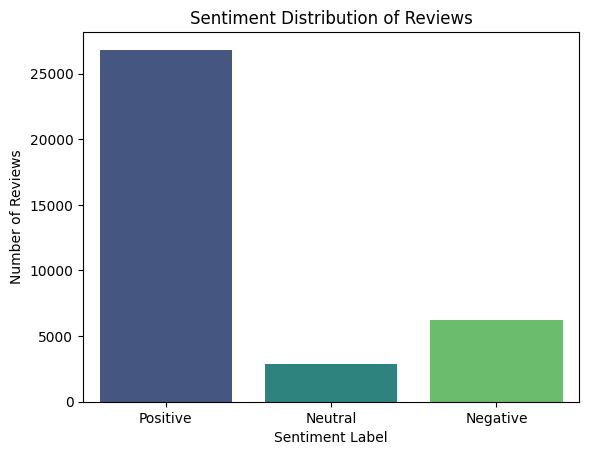

In [4]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm 

nltk.download('vader_lexicon')
tqdm.pandas()
sia = SentimentIntensityAnalyzer()

def analyse_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else: 
        return 'Neutral'

df = pd.read_csv('reviews.csv', encoding='utf-8', on_bad_lines='skip')
df.columns = df.columns.str.strip()
df = df.dropna(subset=['reviews.text'])

df['compound'] = df['reviews.text'].progress_apply(lambda x: sia.polarity_scores(str(x))['compound'])
df['sentiment'] = df['compound'].apply(analyse_sentiment)

print(df[['reviews.text', 'compound', 'sentiment']].head())

sns.countplot(data=df, x='sentiment', palette='viridis', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution of Reviews')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Reviews')
plt.show()